<a href="https://colab.research.google.com/github/norrismeg/odw/blob/main/Data_Challenge_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Challenge 4 (8 points) -- Advanced**

Use the data file challenge3.gwf with channels H1:CHALLENGE3 and L1:CHALLENGE3.

These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.

Any simulated signals have been added to both the H1 and L1 data

All simulated signals have spin = 0 and m1 = m2, with m1 somewhere in the range 10-50 solar masses
1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

2. Identify as many glitches as you can. Make a spectrogram of each one.

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
#! pip install -q pycbc
#! pip install -q gwpy
#! pip install -U -q bilby==2.4.0 matplotlib==3.10.0 dynesty==2.1.5 corner==2.2.3 gwpy==3.0.12 lalsuite==7.25 scipy==1.12.0
# -- Click "restart runtime" in the runtime menu

In [ ]:
# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf

# -- for gwpy
#from gwpy.timeseries import TimeSeries,TimeSeriesDict
#gwpy_strain = TimeSeriesDict.read('challenge3.gwf', ["H1:CHALLENGE3","L1:CHALLENGE3"])
#gwpy_strain_L1 = TimeSeries.read('challenge3.gwf', channel="L1:CHALLENGE3")

# -- for pycbc
#from pycbc import frame
#pycbc_strain = frame.read_frame('challenge3.gwf', ['H1:CHALLENGE3','L1:CHALLENGE3'])
#pycbc_strain_L1 = frame.read_frame('challenge3.gwf', 'L1:CHALLENGE3')

--2025-06-12 07:55:51--  https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 256814830 (245M)
Saving to: ‘challenge3.gwf.1’

challenge3.gwf.1    100%[===================>] 244.92M   207MB/s    in 1.2s    

2025-06-12 07:55:53 (207 MB/s) - ‘challenge3.gwf.1’ saved [256814830/256814830]



/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pkg_resources/__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('ligo')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pkg_resources/__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (

lal.MSUN_SI != Msun
__name__ = gwsurrogate.new.spline_evaluation
__package__= gwsurrogate.new


1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt
#from pycbc.waveform import get_td_waveform
#from pycbc.filter import matched_filter, resample_to_delta_t, highpass
#from pycbc.psd import interpolate, inverse_spectrum_truncation

/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pkg_resources/__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('ligo')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pkg_resources/__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (

lal.MSUN_SI != Msun
__name__ = gwsurrogate.new.spline_evaluation
__package__= gwsurrogate.new
H1
L1


/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


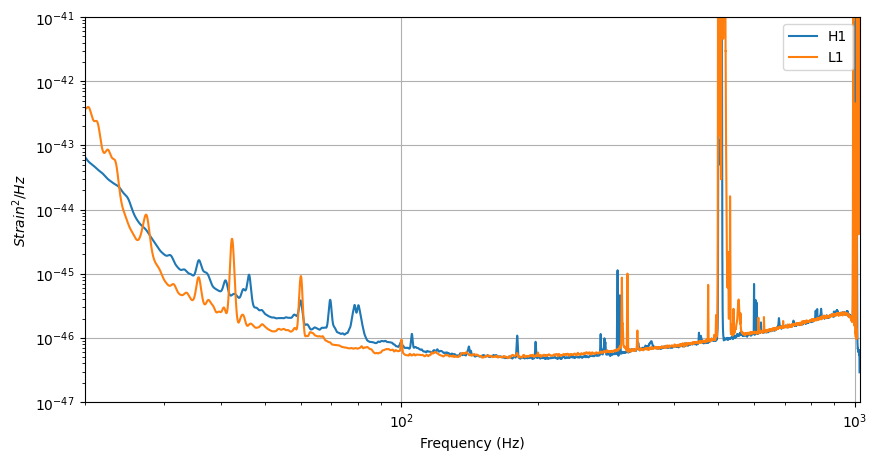

In [3]:
import matplotlib.pyplot as plt
from pycbc import frame
from pycbc.filter import matched_filter, resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation

ifos = ['H1','L1']
pycbc_strain = {}
data = {}
psd = {}

plt.figure(figsize=[10, 5])


for ifo in ifos:
    # Read in and precondition the data
    channel = (ifo)+':CHALLENGE3'
    pycbc_strain[ifo] = frame.read_frame('challenge3.gwf', channel)

for ifo, ts in pycbc_strain.items():
    #print(isinstance(ts,TimeSeries))
    print(ifo)
    t_s = highpass(ts, 15)
    data[ifo] = resample_to_delta_t(t_s, 1.0/2048).crop(2, 2)

    # Estimate the power spectral density of the data
    # This chooses to use 2s samples in the PSD estimate.
    p = data[ifo].psd(2)
    p = interpolate(p, data[ifo].delta_f)
    p = inverse_spectrum_truncation(p, int(2 * data[ifo].sample_rate), low_frequency_cutoff=15.0)
    psd[ifo] = p

    plt.plot(psd[ifo].sample_frequencies, psd[ifo], label=ifo)

plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-47, 1e-41)
plt.xlim(20, 1024)
plt.ylabel('$Strain^2 / Hz$')
plt.xlabel('Frequency (Hz)')
plt.grid()
plt.legend()
plt.show()

In [7]:
from pycbc.detector import Detector

# Calculate the time of flight between each LIGO observatory
d = Detector("L1")
tof = d.light_travel_time_to_detector(Detector("H1"))
print(tof)


0.010012846152267725


26682
26682
13.0283203125


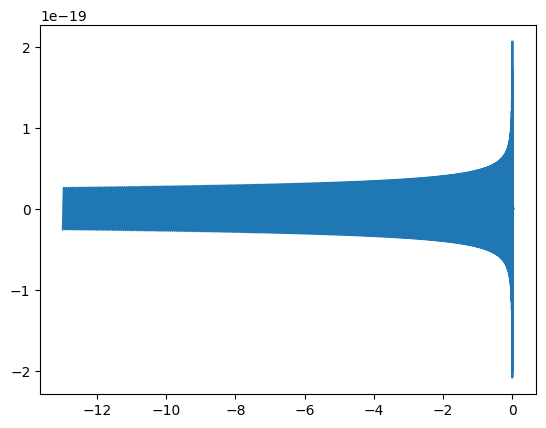

8380416
4092.0


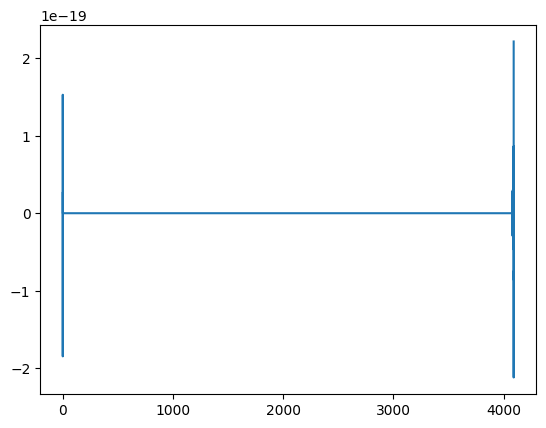

In [4]:
from pycbc.waveform import get_td_waveform

hp1, hc1 = get_td_waveform(approximant="SEOBNRv4_opt",
                            mass1=10,
                            mass2=10,
                            delta_t=data['H1'].delta_t,
                            f_lower=15)
print(len(hp1))
print(len(hc1))
print(hp1.duration)
plt.plot(hp1.sample_times, hp1)
plt.show()
hp1.resize(len(data['H1']))
print(len(hp1))
template = hp1.cyclic_time_shift(hp1.start_time)
print(template.duration)

plt.plot(template.sample_times, template)

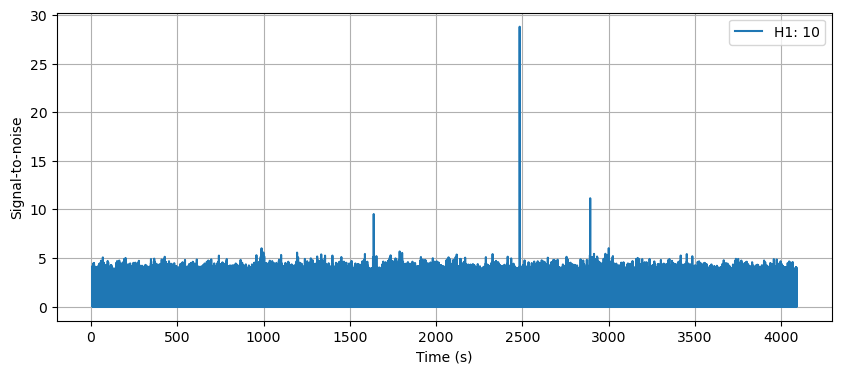

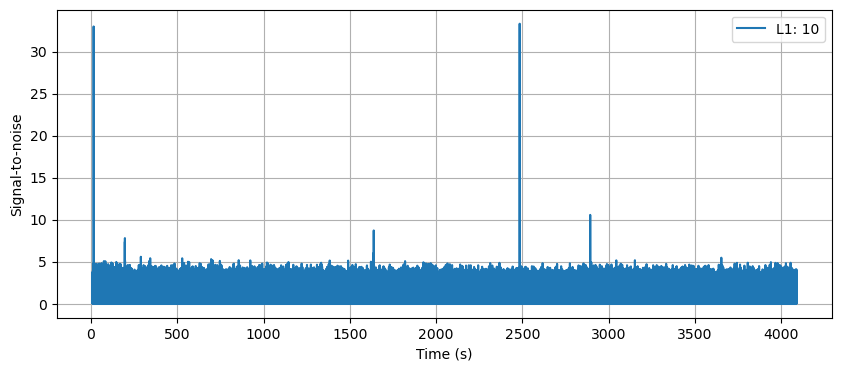

In [12]:
# troubleshooting snr

snr = {}

# plt.figure(figsize=[10, 4])

for ifo, conditioned in data.items():
    snr[ifo] = matched_filter(template, conditioned, psd=psd[ifo], low_frequency_cutoff=15.0)
    snr[ifo] = snr[ifo].crop(5, 4)

    plt.figure(figsize=[10, 4])

    plt.plot(snr[ifo].sample_times, abs(snr[ifo]), label=ifo+': '+str(10))
    
    plt.legend()
    plt.ylabel('Signal-to-noise')
    plt.xlabel('Time (s)')
    plt.grid()
    plt.show()

In [ ]:
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter, resample_to_delta_t, highpass
from scipy.signal import find_peaks
import bisect
from pycbc.vetoes import power_chisq
from pycbc.events.ranking import newsnr

m_range = [m for m in range(10,51,5)]

snr = {}
chisq = {}

signals = [] # List of possible signals
glitches = [] # List of likely glitches

for mass in m_range:
  hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                            mass1=mass,
                            mass2=mass,
                            delta_t=data['H1'].delta_t,
                            f_lower=15.0)
  hp.resize(len(data['H1'])) # why resize it to be the length of the data?
  hp = hp.cyclic_time_shift(hp.start_time) # what time is it being shifted to?
  H1_trig = []
  L1_trig = []

  H1_trig_nsnr = []
  L1_trig_nsnr = []

  for ifo in ifos:
    snr[ifo] = matched_filter(hp, data[ifo], psd=psd[ifo], low_frequency_cutoff=15.0)
    snr[ifo] = snr[ifo].crop(4 + 4, 4)

    # Remove time corrupted by the template filter and the psd filter
    # We remove 4 seconds at the beginning and end for the PSD filtering
    # And we remove 4 additional seconds at the beginning to account for
    # the template length (this is somewhat generous for
    # so short a template). A longer signal such as from a BNS, would
    # require much more padding at the beginning of the vector.

    #plt.figure(figsize=[10, 4])
    #plt.plot(snr[ifo].sample_times, abs(snr[ifo]), label=ifo+': '+str(mass))
    #plt.legend()
    #plt.ylim(0,40)
    #plt.grid()
    #plt.ylabel('Signal-to-noise')
    #plt.xlabel('Time (s)')
    #plt.show()

    snr_peaks, _ = find_peaks(snr[ifo], distance=2048, height=8)
    snr_trig = snr[ifo].sample_times[snr_peaks]
    
    # Add trigger time to list if not on the list already. Keep ifos separate for now
    if ifo == 'H1':
      H1_trig = np.union1d(H1_trig, snr_trig)
    elif ifo == 'L1':
      L1_trig = np.union1d(L1_trig, snr_trig)
    else: print('error')

  for ifo in ifos:
    # The number of bins to use. In principle, this choice is arbitrary. In practice,
    # this is empirically tuned.
    nbins = 26
    chisq[ifo] = power_chisq(hp, data[ifo], nbins, psd[ifo], low_frequency_cutoff=15.0)
    chisq[ifo] = chisq[ifo].crop(4+4, 4)

    dof = nbins * 2 - 2
    chisq[ifo] /= dof

    nsnr = {ifo:newsnr(abs(snr[ifo]), chisq[ifo])}

    nsnr_peaks, _ = find_peaks(nsnr[ifo], distance=2048, height=8)
    nsnr_trig = snr[ifo].sample_times[nsnr_peaks]
    
    # Add trigger time to list if not on the list already. Keep ifos separate for now
    if ifo == 'H1':
      H1_trig_nsnr = np.union1d(H1_trig_nsnr, nsnr_trig)
    elif ifo == 'L1':
      L1_trig_nsnr = np.union1d(L1_trig_nsnr, nsnr_trig)
    else: print('error')

print('H1 Triggers:',H1_trig)
print('L1 Triggers:',L1_trig)

print('H1 Potential Signals:',H1_trig_nsnr)
print('L1 Potential Signals:',L1_trig_nsnr)


    #peak = abs(snr).numpy().argmax()
    #snrp = snr[peak]
    #time = snr.sample_times[peak]

  # If SNR > threshold (10?) and signal occurs in both detectors within 15 ms using the same template, add time, snrp, and template mass to the list of signals
  # If SNR > threshold (10?) and signal only occurs in one detector, add time, snrp, detector, and template mass to the list of glitches

  #print("Mass: {}. We found a signal at {}s with SNR {}".format(mass, time, abs(snrp)))

  # gwpy TimeSeries methods: correlate, find_gates, inject
  # numpy.extract

/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pycbc/types/array.py:225: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = arr.astype(dtype)


H1 Triggers: [ 987.65722656 1101.41943359 1638.14404297 2483.93945312 2892.69628906
 3219.17773438]
L1 Triggers: [ 196.07861328 1101.41894531 1638.14404297 2892.69628906 3219.17773438]
H1 Potential Signals: [3219.1796875]
L1 Potential Signals: [3219.17871094]


In [29]:
print('H1')
print(H1_trig)
print(H1_trig_nsnr)
print('L1')
print(L1_trig)
print(L1_trig_nsnr)

H1
[ 987.65722656 1101.41943359 1638.14404297 2483.93945312 2892.69628906
 3219.17773438]
[ 987.65722656 1101.41943359 1638.14404297 2483.93945312 2892.69628906
 3219.17773438]
L1
[ 196.07861328 1101.41894531 1638.14404297 2892.69628906 3219.17773438]
[ 196.07861328 1101.41894531 1638.14404297 2892.69628906 3219.17773438]


In [20]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(snr['H1'], distance=2048, height=8)

print(peaks)

times = snr['H1'].sample_times[peaks]

print(times)

peaks1, _ = find_peaks(snr['L1'], distance=2048, height=8)
print(peaks1)
times1 = snr['L1'].sample_times[peaks1]
print(times1)

/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/pycbc/types/array.py:225: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = arr.astype(dtype)


[2002242 2235227 3334439 5066628 5903762 6572396]
[ 987.65722656 1101.41943359 1638.14404297 2483.93945312 2892.69628906
 3219.17773438]
[ 381089 2235226 3334439 5903762 6572396]
[ 196.07861328 1101.41894531 1638.14404297 2892.69628906 3219.17773438]


In [6]:
# From ODW tutorial 2.3

from pycbc.vetoes import power_chisq

chisq = {}
for ifo in ifos:
    # The number of bins to use. In principle, this choice is arbitrary. In practice,
    # this is empirically tuned.
    nbins = 26
    chisq[ifo] = power_chisq(hp, data[ifo], nbins, psd[ifo], low_frequency_cutoff=15.0)
    chisq[ifo] = chisq[ifo].crop(4+4, 4)

    dof = nbins * 2 - 2
    chisq[ifo] /= dof

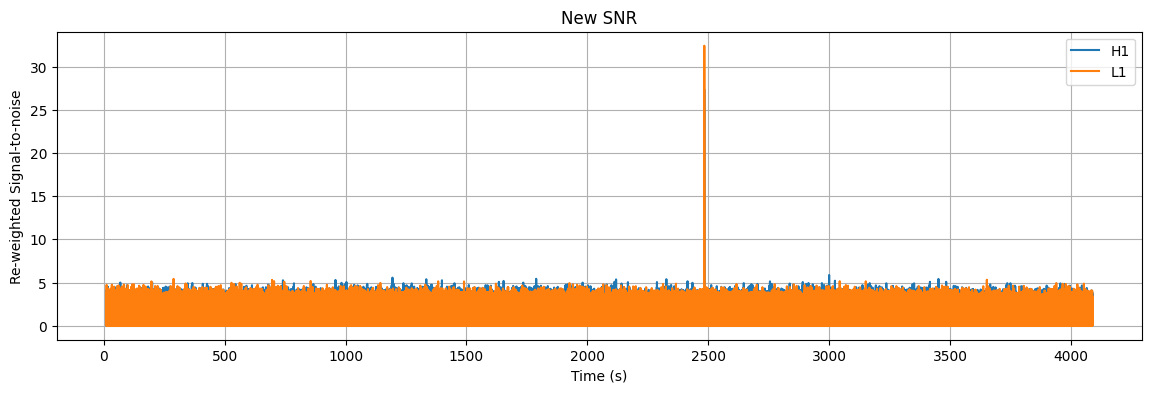

In [12]:
# From ODW tutorial 2.3

from pycbc.events.ranking import newsnr

# The rho-hat term above is named "newsnr" here
nsnr = {ifo:newsnr(abs(snr[ifo]), chisq[ifo]) for ifo in ifos}

# Show a couple sizes
plt.figure(figsize=[14, 4])
for ifo in ifos:
    plt.plot(snr[ifo].sample_times, nsnr[ifo], label=ifo)

plt.legend()
plt.title('New SNR')
plt.grid()
#plt.xlim(2483.9,2484)
plt.xlabel('Time (s)')
plt.ylabel('Re-weighted Signal-to-noise')
plt.show()

In [ ]:
#for coin in coins:
  #if coin == True:
    #print(coin)

In [ ]:
np.where(coins==True)[0]

array([  74,   99,  107, ..., 4047, 4068, 4071])

In [ ]:
len(np.where(coins==True)[0])

296

In [ ]:
array = [[1,3],[2,3],[3,9],[4,4],[5,3],[6,3],[7,15],[8,4],[9,4],[10,3]]

snr_peaks = np.where(abs(snr)>8)[0] # need index because np.where returns a tuple
print(snr_peaks)

[  10200   10203   10204   10205   10206   10207   10208   10209
   10210   10211   10212   10213   10214   10215   10216   10217
   10218   10219   10220   10221   10222   10223   10224   10225
   10226   10227   10228   10229   10230   10231   10232   10233
   10234   10235   10237   10238   10239 3334508 3334509 3334510
 3334511 3334512 3334513 3334673 3334674 3334675 3334676 3334677
 5066666 5066667 5066668 5066669 5066670 5066671 5066672 5066673
 5066674 5066675 5066676 5066677 5066678 5066679 5066680 5066681
 5066682 5066683 5066684 5066685 5066686 5066687 5066688 5066689
 5066690 5066691 5066692 5066693 5066694 5066695 5066696 5066697
 5066698 5066699 5066700 5066701 5066702 5066703 5066704 5066705
 5903795 5903796 5903797 5903807 5903808 5903809 5903810 5903811
 5903812 5903813 5903921 5903922 5903923 5903924 5903925 5903926
 5903927 5903928 5903929 5903930 5903931 5903932 5903933 5903934
 5903935 5903936 5903937 5903938 5903939 5903940 5903941 5903942
 5903943 5903944 5903945 

In [ ]:
candidates = [np.array([abs(snr)[i],snr.sample_times[i]]) for i in snr_peaks]

#for i, index in enumerate(snr_peaks):
  #snrp = abs(snr)[index]
  #time = snr.sample_times[index]
  #candidates.append(np.array([time,abs(snrp)]))
  #print("Mass: {}. We found a signal at {}s with SNR {}".format(mass, time, abs(snrp)))

print(candidates)

[array([ 8.6567097 , 14.98046875]), array([ 8.71643522, 14.98193359]), array([ 9.89463078, 14.98242188]), array([ 9.19197785, 14.98291016]), array([ 8.61871544, 14.98339844]), array([11.15966835, 14.98388672]), array([13.69316789, 14.984375  ]), array([13.20362755, 14.98486328]), array([10.19565475, 14.98535156]), array([12.67653318, 14.98583984]), array([18.71960736, 14.98632812]), array([21.3408401 , 14.98681641]), array([16.46869553, 14.98730469]), array([10.46499366, 14.98779297]), array([18.98457015, 14.98828125]), array([30.05886983, 14.98876953]), array([32.97812676, 14.98925781]), array([21.48425251, 14.98974609]), array([14.15488973, 14.99023438]), array([23.68372053, 14.99072266]), array([23.41223238, 14.99121094]), array([18.33047932, 14.99169922]), array([17.11089955, 14.9921875 ]), array([17.94030083, 14.99267578]), array([16.62699285, 14.99316406]), array([14.85419229, 14.99365234]), array([15.50544935, 14.99414062]), array([16.4273031 , 14.99462891]), array([14.58366298,

In [ ]:
np.array(candidates)

array([[   8.6567097 ,   14.98046875],
       [   8.71643522,   14.98193359],
       [   9.89463078,   14.98242188],
       ...,
       [   8.83984472, 2892.80908203],
       [   8.81348715, 2892.80957031],
       [   8.43045079, 2892.81005859]])

2. Identify as many glitches as you can. Make a spectrogram of each one.

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [ ]:
import bilby

# Make bilby more terse
bilby.core.utils.log.setup_logger(log_level='WARNING')

sampling_rate = 2048  # needs to be high enough for the signals found in steps above
duration = 8  # needs to be long enough for the signals found in steps above
start_time = 100  # needs to be set so that the segment defined by [start_time,start_time+duration] contains the signal

interferometers = bilby.gw.detector.InterferometerList([])
for ifo_name in ['H1', 'L1']:
    ifo = bilby.gw.detector.get_empty_interferometer(ifo_name)
    ifo.set_strain_data_from_frame_file('challenge3.gwf', sampling_rate, duration, start_time=start_time, channel=f'{ifo_name}:CHALLENGE3')
    interferometers.append(ifo)

In [ ]:
print(interferometers)

[Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05), Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.10/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)]


In [ ]:
chirp_mass_min = 10/(2**(1/5))
chirp_mass_max = 50/(2**(1/5))
print(chirp_mass_min,chirp_mass_max)

8.705505632961241 43.527528164806206


In [ ]:
chirp_mass_min = 10/(2**(1/5))
chirp_mass_max = 50/(2**(1/5))
print(chirp_mass_min,chirp_mass_max)

prior = bilby.core.prior.PriorDict()
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=chirp_mass_min,maximum=chirp_mass_max)
prior['mass_ratio'] = 1.0
prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=time_of_event-0.1, maximum=time_of_event+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
#prior['dec'] =  -1.2232
#prior['ra'] =  2.19432
#prior['theta_jn'] =  1.89694
#prior['psi'] =  0.532268
prior['luminosity_distance'] = PowerLaw(alpha=2, name='luminosity_distance', minimum=50, maximum=2000, unit='Mpc', latex_label='$d_L$')


8.705505632961241 43.527528164806206


NameError: name 'Uniform' is not defined